Dashboard successfully generated and saved to output.png


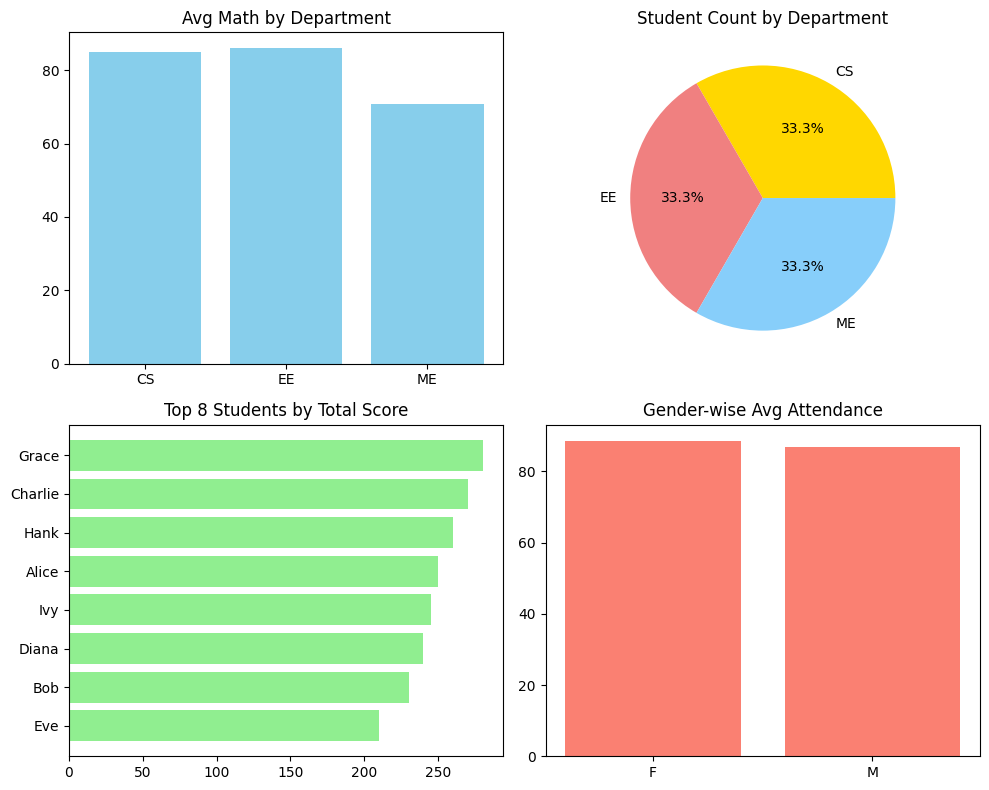

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# 1. Setup in-memory Database with sample data
conn = sqlite3.connect(':memory:')
conn.execute('''
    CREATE TABLE students (
        id INTEGER PRIMARY KEY, name TEXT, department TEXT,
        gender TEXT, math_score REAL, total_score REAL, attendance REAL
    )
''')
conn.executemany('INSERT INTO students VALUES (?,?,?,?,?,?,?)', [
    (1, 'Alice', 'CS', 'F', 85, 250, 90),
    (2, 'Bob', 'CS', 'M', 75, 230, 85),
    (3, 'Charlie', 'EE', 'M', 90, 270, 95),
    (4, 'Diana', 'EE', 'F', 80, 240, 88),
    (5, 'Eve', 'ME', 'F', 70, 210, 80),
    (6, 'Frank', 'ME', 'M', 60, 200, 75),
    (7, 'Grace', 'CS', 'F', 95, 280, 98),
    (8, 'Hank', 'EE', 'M', 88, 260, 92),
    (9, 'Ivy', 'ME', 'F', 82, 245, 87)
])

# 2. SQL Queries based on README
# Panel 1 data: avg math by department
df1 = pd.read_sql('SELECT department, AVG(math_score) as avg_math FROM students GROUP BY department', conn)
# Panel 2 data: student count by department
df2 = pd.read_sql('SELECT department, COUNT(id) as student_count FROM students GROUP BY department', conn)
# Panel 3 data: top 8 students by total score
df3 = pd.read_sql('SELECT name, total_score FROM students ORDER BY total_score DESC LIMIT 8', conn)
# Panel 4 data: gender-wise average attendance
df4 = pd.read_sql('SELECT gender, AVG(attendance) as avg_att FROM students GROUP BY gender', conn)

# 3. Matplotlib Visualization
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# Panel 1 (top-left): Avg Math by Department - BAR Chart
axs[0, 0].bar(df1['department'], df1['avg_math'], color='skyblue')
axs[0, 0].set_title('Avg Math by Department')

# Panel 2 (top-right): Student Count - Pie Chart
axs[0, 1].pie(df2['student_count'], labels=df2['department'], autopct='%1.1f%%', colors=['gold', 'lightcoral', 'lightskyblue'])
axs[0, 1].set_title('Student Count by Department')

# Panel 3 (bottom-left): Top 8 Students - Horizontal Bar
axs[1, 0].barh(df3['name'], df3['total_score'], color='lightgreen')
axs[1, 0].set_title('Top 8 Students by Total Score')
axs[1, 0].invert_yaxis() # Highest score at the top

# Panel 4 (bottom-right): Gender Avg Attendance - Bar
axs[1, 1].bar(df4['gender'], df4['avg_att'], color='salmon')
axs[1, 1].set_title('Gender-wise Avg Attendance')

plt.tight_layout()
plt.savefig('output.png')
print("Dashboard successfully generated and saved to output.png")